# Entropic plans on disk and annulus point clouds

This notebook generates `fig:sinkhorn-plan-epsilon`.  It uses the canonical geometry requested for the book figures: the source measure $\alpha$ is supported on a central disk and the target measure $\beta$ on a thin annulus.  For each temperature, the Sinkhorn plan is computed with POT from the squared Euclidean cost, and the notebook checks the marginal residuals before exporting.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Polygon

from figure_style import (
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    RED,
    VIOLET,
    box_axes,
    canonical_matching_clouds,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
np.random.seed(0)

POINT_SIZE = 8.6


def active_pairs(P, rel_threshold=0.18, max_pairs=180):
    order = np.argsort(P.ravel())[::-1]
    pairs = []
    cutoff = rel_threshold * P.max()
    for flat in order:
        mass = float(P.ravel()[flat])
        if mass < cutoff:
            break
        i, j = np.unravel_index(flat, P.shape)
        pairs.append((int(i), int(j), mass))
        if len(pairs) >= max_pairs:
            break
    return pairs


def draw_clouds(ax, x, y, *, alpha=1.0, size=POINT_SIZE, zorder=4):
    ax.scatter(x[:, 0], x[:, 1], s=size, marker="o", color=RED, alpha=alpha, edgecolor="none", zorder=zorder)
    ax.scatter(y[:, 0], y[:, 1], s=size, marker="o", color=BLUE, alpha=alpha, edgecolor="none", zorder=zorder)


def draw_segments(ax, x, y, pairs, *, color=VIOLET, min_width=0.10, max_width=1.15, alpha=0.56, zorder=1):
    if not pairs:
        return
    masses = np.array([m for _, _, m in pairs], dtype=float)
    rel = masses / max(masses.max(), 1e-15)
    segments = [[x[i], y[j]] for i, j, _ in pairs]
    base = np.array(to_rgb(color))
    colors = [(*base, min(alpha * (0.18 + 0.82 * np.sqrt(r)), 0.88)) for r in rel]
    widths = min_width + (max_width - min_width) * np.sqrt(rel)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths, zorder=zorder))


def set_cloud_limits(ax, x, y, pad=0.18):
    (xmin, xmax), (ymin, ymax) = padded_limits(np.vstack([x, y]), pad=pad)
    span = max(xmax - xmin, ymax - ymin)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    ax.set_xlim(cx - span / 2, cx + span / 2)
    ax.set_ylim(cy - span / 2, cy + span / 2)
    ax.set_aspect("equal")
    remove_axes(ax)

## Semi-regular disk and annulus samples

The point clouds are generated by farthest-point subsampling from many random candidates, followed by a tiny jitter of about $30\%$ of the nearest-neighbor spacing.  This keeps the visual regular enough for transport geometry while avoiding an artificial grid.

In [2]:
fig_name = "sinkhorn-plan-epsilon"
out = figure_dir(fig_name)

rng = np.random.default_rng(2027)


def sample_disk_candidates(count, radius=0.50):
    theta = rng.uniform(0.0, 2.0 * np.pi, count)
    r = radius * np.sqrt(rng.uniform(0.0, 1.0, count))
    return np.c_[r * np.cos(theta), r * np.sin(theta)]


def sample_annulus_candidates(count, inner=0.85, outer=1.00):
    theta = rng.uniform(0.0, 2.0 * np.pi, count)
    r = np.sqrt(inner**2 + (outer**2 - inner**2) * rng.uniform(0.0, 1.0, count))
    return np.c_[r * np.cos(theta), r * np.sin(theta)]


def farthest_subset(candidates, n, first=None):
    candidates = np.asarray(candidates)
    if first is None:
        first = int(np.argmin(np.sum(candidates**2, axis=1)))
    selected = [first]
    dist2 = np.sum((candidates - candidates[first])**2, axis=1)
    for _ in range(1, n):
        idx = int(np.argmax(dist2))
        selected.append(idx)
        dist2 = np.minimum(dist2, np.sum((candidates - candidates[idx])**2, axis=1))
    return candidates[selected]


def jitter(points, factor=0.30):
    d2 = np.sum((points[:, None, :] - points[None, :, :])**2, axis=2)
    np.fill_diagonal(d2, np.inf)
    scale = factor * float(np.mean(np.sqrt(np.min(d2, axis=1))))
    return points + rng.normal(scale=scale, size=points.shape)


x = jitter(farthest_subset(sample_disk_candidates(4800), 42, first=0), factor=0.30)
y = jitter(farthest_subset(sample_annulus_candidates(6400), 56, first=0), factor=0.30)
a = np.ones(len(x)) / len(x)
b = np.ones(len(y)) / len(y)
C = ot.dist(x, y, metric="sqeuclidean")
C = C / np.median(C[C > 0])

epsilons = [
    (0.018, "eps-0p018.pdf", 0.48, 70),
    (0.045, "eps-0p045.pdf", 0.30, 120),
    (0.120, "eps-0p120.pdf", 0.17, 210),
    (0.320, "eps-0p320.pdf", 0.085, 320),
]


## Exported coupling panels

Segments have width and opacity proportional to the visible transported mass.  Small `epsilon` gives a nearly sparse geometry; large `epsilon` spreads mass across many source-target pairs.

In [3]:
for epsilon, filename, rel_threshold, max_pairs in epsilons:
    plan, log = ot.sinkhorn(
        a,
        b,
        C,
        reg=epsilon,
        method="sinkhorn_log",
        log=True,
        numItermax=80000,
        stopThr=1e-11,
    )
    residual = max(np.abs(plan.sum(axis=1) - a).sum(), np.abs(plan.sum(axis=0) - b).sum())
    if residual > 5e-7:
        raise RuntimeError(f"Sinkhorn residual too large for epsilon={epsilon}: {residual:.2e}")
    pairs = active_pairs(plan, rel_threshold=rel_threshold, max_pairs=max_pairs)
    fig, ax = plt.subplots(figsize=(2.12, 2.12))
    draw_segments(ax, x, y, pairs, min_width=0.06, max_width=0.98, alpha=0.56, zorder=1)
    draw_clouds(ax, x, y, size=POINT_SIZE, zorder=3)
    set_cloud_limits(ax, x, y, pad=0.10)
    save_pdf(fig, out / filename, pad_inches=0.040)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


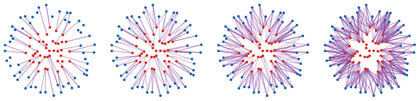

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-plan-epsilon.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-plan-epsilon.png")
display(Image(filename=str(_thumb)))
